In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

In [2]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

metadata_path = (
    PROCESSED_DIR
    / "eurosat_spatial_metadata.csv"
)

print(metadata_path)

c:\Users\ASUS\dev\projects\satellite-project\data\processed\eurosat_spatial_metadata.csv


In [3]:
metadata_df = pd.read_csv(metadata_path)

print(metadata_df.shape)

metadata_df.head()

(27597, 5)


,filepath_rgb,filepath_tif,class_name,center_lat,center_lon
0,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,44.035220,28.559055
1,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,39.085801,-1.829726
2,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,48.977295,4.239720
3,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,48.892610,4.089878
4,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,51.832851,18.084960


In [4]:
classes = sorted(
    metadata_df["class_name"].unique()
)

class_to_idx = {
    cls: idx
    for idx, cls in enumerate(classes)
}

metadata_df["class_id"] = (
    metadata_df["class_name"]
    .map(class_to_idx)
)

metadata_df.head()

,filepath_rgb,filepath_tif,class_name,center_lat,center_lon,class_id
0,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,44.035220,28.559055,0
1,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,39.085801,-1.829726,0
2,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,48.977295,4.239720,0
3,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,48.892610,4.089878,0
4,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,51.832851,18.084960,0


In [5]:
metadata_df[
    [
        "center_lat",
        "center_lon"
    ]
].describe()

,center_lat,center_lon
count,27597.000000,27597.000000
mean,47.098877,10.977196
std,9.432909,16.719916
min,-5.428416,-20.993892
25%,43.596446,1.855008
50%,48.727699,8.299807
75%,52.182263,16.697739
max,65.237817,106.807624


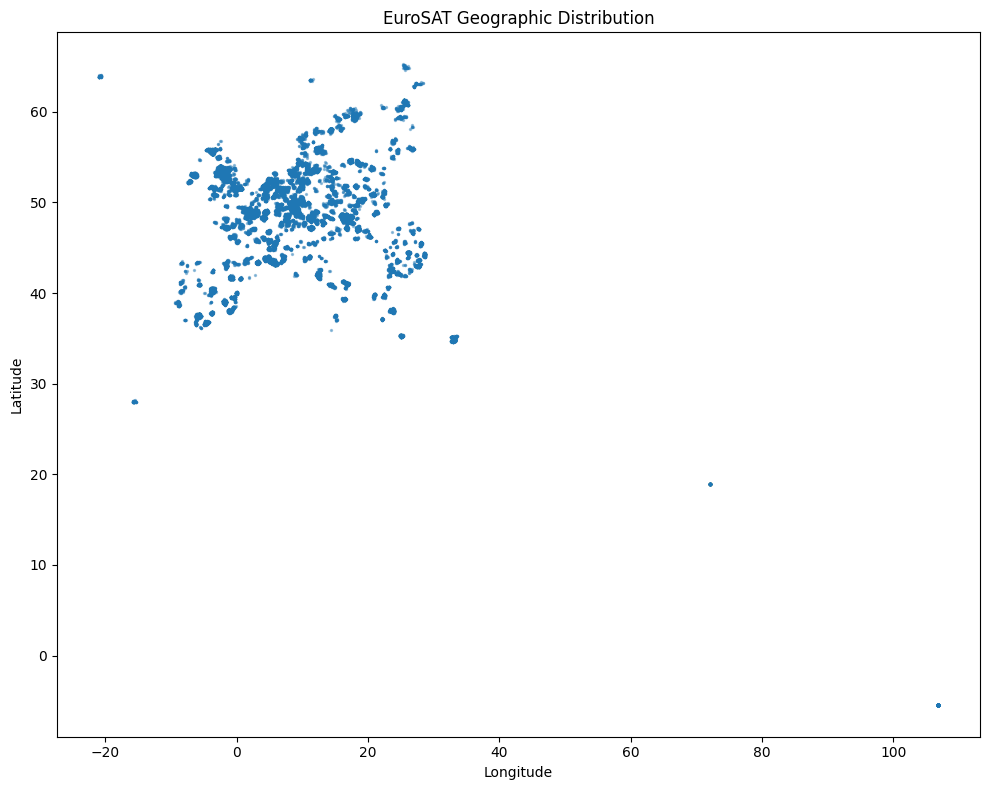

In [6]:
plt.figure(figsize=(10, 8))

plt.scatter(
    metadata_df["center_lon"],
    metadata_df["center_lat"],
    s=2,
    alpha=0.4
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("EuroSAT Geographic Distribution")

plt.tight_layout()
plt.show()

In [7]:
coords = metadata_df[
    [
        "center_lat",
        "center_lon"
    ]
].values

coords.shape

(27597, 2)

In [8]:
N_CLUSTERS = 8

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10
)

metadata_df["geo_cluster"] = (
    kmeans.fit_predict(coords)
)

In [9]:
metadata_df["geo_cluster"] \
    .value_counts() \
    .sort_index()

geo_cluster
0    4542
1     512
2    9826
3    2774
4    3846
5    2658
6    3354
7      85
Name: count, dtype: int64

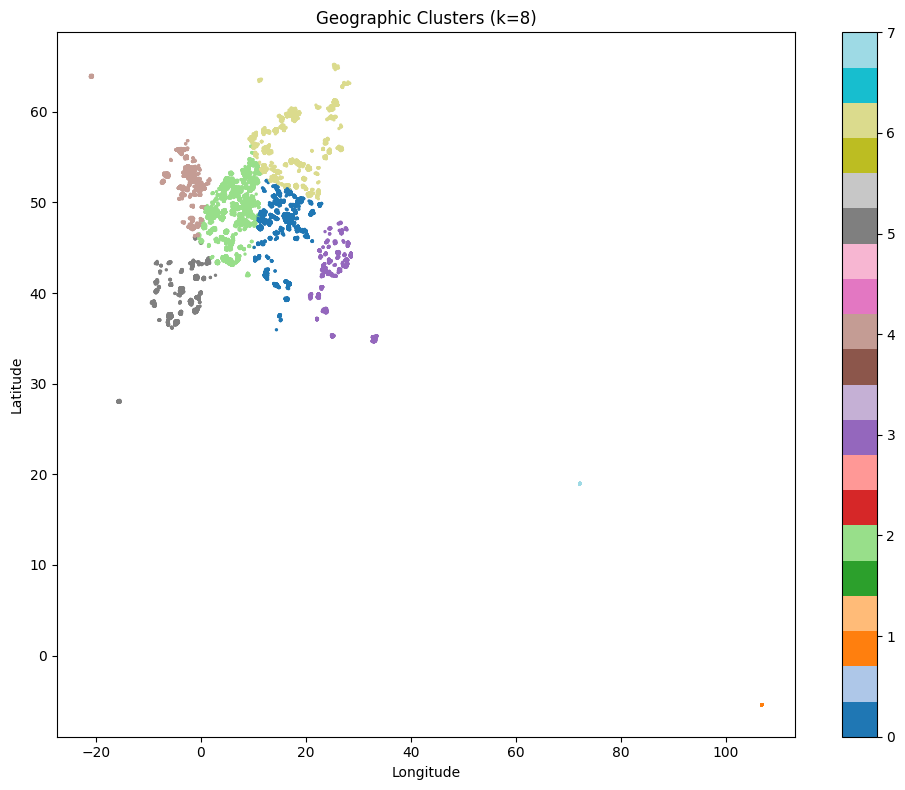

In [10]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    metadata_df["center_lon"],
    metadata_df["center_lat"],
    c=metadata_df["geo_cluster"],
    s=2,
    cmap="tab20"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    f"Geographic Clusters (k={N_CLUSTERS})"
)

plt.colorbar(scatter)

plt.tight_layout()
plt.show()

In [11]:
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=[
        "center_lat",
        "center_lon"
    ]
)

cluster_centers

,center_lat,center_lon
0,46.658630,15.439160
1,-5.428416,106.807624
2,48.822409,6.063698
3,40.416688,26.286929
4,52.858067,-2.874464
5,39.556106,-3.306857
6,56.296093,17.719278
7,18.967751,72.153969


In [12]:
cluster_class_table = pd.crosstab(
    metadata_df["geo_cluster"],
    metadata_df["class_name"]
)

cluster_class_table

class_name,AnnualCrop,Forest,HerbaceousVegetation,Highway,Industrial,Pasture,PermanentCrop,Residential,River,SeaLake
geo_cluster,,,,,,,,,,
0,629,727,323,364,444,112,480,411,577,475
1,0,0,0,0,0,0,0,0,0,512
2,1470,1275,234,989,1043,391,1201,1246,1280,697
3,282,430,812,70,162,42,304,371,70,231
4,67,19,903,299,380,1356,50,397,156,219
5,275,105,707,399,244,22,465,247,107,87
6,277,444,21,379,227,77,0,328,310,1291
7,0,0,0,0,0,0,0,0,0,85


In [13]:
cluster_class_pct = (
    cluster_class_table
    .div(
        cluster_class_table.sum(axis=1),
        axis=0
    )
)

cluster_class_pct.round(3)

class_name,AnnualCrop,Forest,HerbaceousVegetation,Highway,Industrial,Pasture,PermanentCrop,Residential,River,SeaLake
geo_cluster,,,,,,,,,,
0,0.138,0.160,0.071,0.080,0.098,0.025,0.106,0.090,0.127,0.105
1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
2,0.150,0.130,0.024,0.101,0.106,0.040,0.122,0.127,0.130,0.071
3,0.102,0.155,0.293,0.025,0.058,0.015,0.110,0.134,0.025,0.083
4,0.017,0.005,0.235,0.078,0.099,0.353,0.013,0.103,0.041,0.057
5,0.103,0.040,0.266,0.150,0.092,0.008,0.175,0.093,0.040,0.033
6,0.083,0.132,0.006,0.113,0.068,0.023,0.000,0.098,0.092,0.385
7,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000


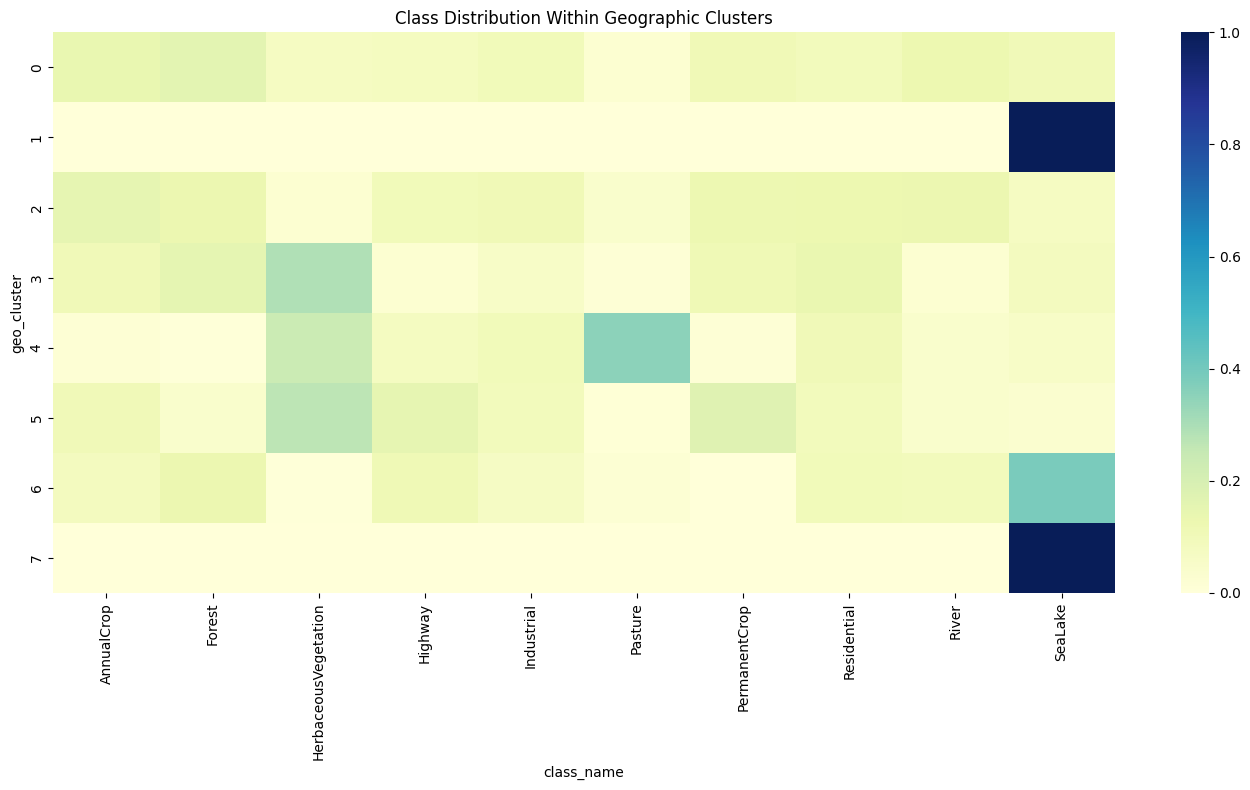

In [14]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    cluster_class_pct,
    cmap="YlGnBu"
)

plt.title(
    "Class Distribution Within Geographic Clusters"
)

plt.tight_layout()
plt.show()

In [15]:
cluster_sizes = (
    metadata_df["geo_cluster"]
    .value_counts()
    .sort_index()
)

cluster_sizes

geo_cluster
0    4542
1     512
2    9826
3    2774
4    3846
5    2658
6    3354
7      85
Name: count, dtype: int64

In [16]:
coverage = (
    cluster_class_table > 0
).sum(axis=1)

coverage

geo_cluster
0    10
1     1
2    10
3    10
4    10
5    10
6     9
7     1
dtype: int64

In [17]:
save_path = (
    PROCESSED_DIR
    / "eurosat_geo_clusters.csv"
)

metadata_df.to_csv(
    save_path,
    index=False
)

print(save_path)

c:\Users\ASUS\dev\projects\satellite-project\data\processed\eurosat_geo_clusters.csv


In [18]:
metadata_df = metadata_df[
    metadata_df["filepath_rgb"]
    .apply(lambda x: Path(x).exists())
].copy()

print(metadata_df.shape)

(27000, 7)


In [19]:
cluster_sizes = (
    metadata_df["geo_cluster"]
    .value_counts()
)

small_clusters = cluster_sizes[
    cluster_sizes < 1000
]

print(small_clusters)

Series([], Name: count, dtype: int64)


In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

coords = metadata_df[
    ["center_lat", "center_lon"]
].values

scores = {}

for k in range(5, 21):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(coords)

    score = silhouette_score(
        coords,
        labels
    )

    scores[k] = score

    print(k, score)

5 0.4487405197500071
6 0.44478496528390227
7 0.4469745502563495
8 0.4533459500047277
9 0.46844229715377816
10 0.4810518171209894
11 0.4799506442540155
12 0.4922886114924858
13 0.4822094129364104
14 0.4968431166909251
15 0.5012882190198082
16 0.49213545610614723
17 0.4903770869532295
18 0.46119821818791285
19 0.48155950648762375
20 0.4987375052923708


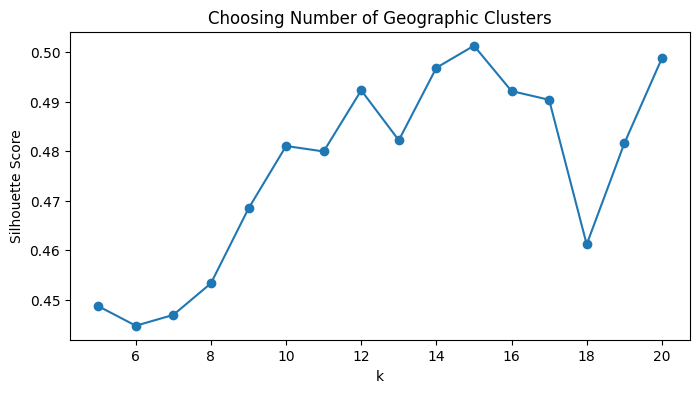

In [21]:
plt.figure(figsize=(8,4))

plt.plot(
    list(scores.keys()),
    list(scores.values()),
    marker="o"
)

plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Choosing Number of Geographic Clusters")

plt.show()

In [22]:
metadata_df["geo_cluster"] = pd.DataFrame(kmeans.labels_)

In [23]:
metadata_df["geo_cluster"]

0        3
1        5
2        2
3        2
4        6
        ..
27592    0
27593    6
27594    2
27595    2
27596    2
Name: geo_cluster, Length: 27000, dtype: int32

In [24]:
outliers = metadata_df[
    (metadata_df["center_lon"] > 40) |
    (metadata_df["center_lon"] < -15) |
    (metadata_df["center_lat"] < 30)
]

print(outliers.shape)

outliers[
    ["class_name", "center_lat", "center_lon"]
].head(20)

(95, 7)


,class_name,center_lat,center_lon
6027,HerbaceousVegetation,63.903563,-20.779087
6054,HerbaceousVegetation,63.877904,-20.940952
6114,HerbaceousVegetation,63.872084,-20.980660
6147,HerbaceousVegetation,27.984645,-15.708209
6161,HerbaceousVegetation,28.043685,-15.742836
6193,HerbaceousVegetation,28.073352,-15.690645
6257,HerbaceousVegetation,28.055582,-15.723589
6344,HerbaceousVegetation,63.909328,-20.739305
6451,HerbaceousVegetation,28.079252,-15.684069
6528,HerbaceousVegetation,63.872067,-20.927732


In [25]:
outliers.value_counts("class_name")

class_name
HerbaceousVegetation    71
River                   12
Residential              4
Industrial               4
SeaLake                  3
Highway                  1
Name: count, dtype: int64

A small number of geographically isolated patches (<0.5% of the dataset) were retained in their assigned geographic clusters.

In [26]:
metadata_df.to_csv(
    PROCESSED_DIR / "eurosat_geo_clusters.csv",
    index=False
)

In [27]:
cluster_class_table


class_name,AnnualCrop,Forest,HerbaceousVegetation,Highway,Industrial,Pasture,PermanentCrop,Residential,River,SeaLake
geo_cluster,,,,,,,,,,
0,629,727,323,364,444,112,480,411,577,475
1,0,0,0,0,0,0,0,0,0,512
2,1470,1275,234,989,1043,391,1201,1246,1280,697
3,282,430,812,70,162,42,304,371,70,231
4,67,19,903,299,380,1356,50,397,156,219
5,275,105,707,399,244,22,465,247,107,87
6,277,444,21,379,227,77,0,328,310,1291
7,0,0,0,0,0,0,0,0,0,85


In [28]:
cluster_sizes


geo_cluster
2    9826
0    4542
4    3846
6    3354
3    2774
5    2658
Name: count, dtype: int64

In [29]:
coverage

geo_cluster
0    10
1     1
2    10
3    10
4    10
5    10
6     9
7     1
dtype: int64